In [65]:
from dataset_ae import EASGDatasetAE, EASGData
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch
from utils import *

# USE BATCH SIZE=1 TO USE OUR EVALUATION FUNCTIONS

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
val_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
train_dataset = EASGDatasetAE(path_annts, path_data, 'train', verbs, objs, rels)
val_dataset = EASGDatasetAE(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
triplets_original = [train_original[i]['triplets'] for i in range(len(train_original))]
triplets_original_sorted = [torch.Tensor(sorted(el.tolist())).to(torch.int) for el in triplets_original]
triplets_original_val = [val_original[i]['triplets'] for i in range(len(val_original))]
triplets_original_sorted_val = [torch.Tensor(sorted(el.tolist())).to(torch.int) for el in triplets_original_val]

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 


In [3]:
# load the vae
from utils import load_model, get_pred_and_gt, verb_accuracy, handle_verbs_out, to_triplets, topk_verb_accuracy
from evaluation_utils import find_checkpoint

model_path_vae = find_checkpoint('experiments/vae_balanced_losses/', 4517)
graph_type = 'gat'
print(model_path_vae)
vae = load_model('vae', model_path_vae, separate=True, output_dim=256, graph_type=graph_type)

experiments/vae_balanced_losses/VAE1000_balancedL_gat_sep=True_fromae=False_od=256_kld=mean_b=1.0_drop=0.2_lr=0.0001_fl=False_ex=False_eps=1.0_1726654517/checkpoints/last.ckpt
Using separate mlp for verb and rels, removing shared mlp...
Using vae with focal loss...


# VAE posterior sampling given an input on trainset

In [71]:
# verbs_output_vae, verbs_gt_vae, objs_output_vae, objs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, train_loader)
verbs_output_vae, verbs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, train_loader)
pred_vae = get_pred_triplets(verbs_output_vae, rels_output_vae)

In [72]:
k=2
verbs_predictions_vae = handle_verbs_out(verbs_output_vae)
topk = topk_verb_accuracy(verbs_gt_vae, verbs_output_vae, k)
print(f"{(verb_accuracy(verbs_predictions_vae, verbs_gt_vae)):.3f} %")
print(f"top{k} verb accuracy={topk}")

99.032 %
top2 verb accuracy=99.81684981684981


In [73]:
# triplets that should be present but instead are predicted empty
count=0 
for el in pred_vae:
    if el.numel()==0:
        count+=1
print(f"{(count*100/len(pred_vae)):.3f} %")

0.000 %


In [69]:
correct_vae = 0
error_indices_vae = []
for i in range(len(triplets_original_sorted)):
    if triplets_original_sorted[i].size(0) == pred_vae[i].size(0):
        triplets_original_sorted[i] = triplets_original_sorted[i].to(device)
        if torch.all((triplets_original_sorted[i] == pred_vae[i])):
            correct_vae += 1
    else:
        error_indices_vae.append(i)
print(f"{(correct_vae*100/len(triplets_original_sorted)):.2f} %")

92.73 %


# VAE posterior sampling given an input on validation set

In [4]:
# verbs_output_vae, verbs_gt_vae, objs_output_vae, objs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, val_loader)
verbs_output_vae, verbs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, val_loader)
pred_vae = get_pred_triplets(verbs_output_vae, rels_output_vae)

In [ ]:
k=2
verbs_predictions_vae = handle_verbs_out(verbs_output_vae)
topk = topk_verb_accuracy(verbs_gt_vae, verbs_output_vae, k)
print(f"{(verb_accuracy(verbs_predictions_vae, verbs_gt_vae)):.3f} %")
print(f"top{k} verb accuracy={topk}")

In [94]:
# triplets that should be present but instead are predicted empty
count=0 
for el in pred_vae:
    if el.numel()==0:
        count+=1
print(f"{(count*100/len(pred_vae)):.3f} %")

17.464 %


In [95]:
correct_vae = 0
error_indices_vae = []
for i in range(len(triplets_original_sorted_val)):
    if triplets_original_sorted_val[i].size(0) == pred_vae[i].size(0):
        triplets_original_sorted_val[i] = triplets_original_sorted_val[i].to(device)
        if torch.all((triplets_original_sorted_val[i] == pred_vae[i])):
            correct_vae += 1
    else:
        error_indices_vae.append(i)
print(f"{(correct_vae*100/len(triplets_original_sorted_val)):.2f} %")

0.67 %


# Prior Sampling (From a Random Latent Space Vector)

In [5]:
from utils import get_pred_triplets

In [6]:
num_samples = 10000
codes_dim = 256

decoder = vae.decoder.to(device)
decoded_samples = decoder(torch.randn(num_samples, codes_dim).to(device))
decoded_triplets = get_pred_triplets(decoded_samples[0], decoded_samples[1])

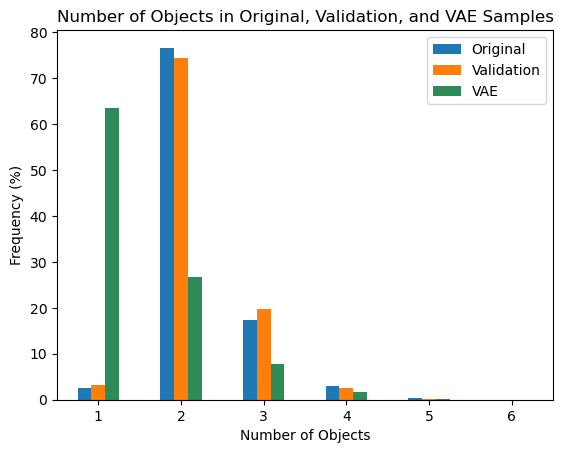

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the number of objects in each training, validation, and VAE sample
num_objects_train = [triplets_original[i].size(0) for i in range(len(triplets_original))]
num_objects_val = [triplets_original_val[i].size(0) for i in range(len(triplets_original_val))]
num_objects_diff = [decoded_triplets[i].size(0) for i in range(len(decoded_triplets))]

# Convert to pandas Series
objects_train_pd = pd.Series(num_objects_train, name='Original')
objects_val_pd = pd.Series(num_objects_val, name='Validation')
objects_diff_pd = pd.Series(num_objects_diff, name='VAE')

# Get value counts and sort by index
objects_train_count = objects_train_pd.value_counts().sort_index()
objects_train_count = objects_train_count * 100 / objects_train_count.sum()

objects_val_count = objects_val_pd.value_counts().sort_index()
objects_val_count = objects_val_count * 100 / objects_val_count.sum()

objects_diff_count = objects_diff_pd.value_counts().sort_index()
objects_diff_count = objects_diff_count * 100 / objects_diff_count.sum()

# Combine all Series into a DataFrame
objects_count_df = pd.DataFrame({
    'Original': objects_train_count, 
    'Validation': objects_val_count,
    'VAE': objects_diff_count
}).fillna(0)

# Plot the data
objects_count_df.plot.bar(color=['#1f77b4', '#ff7f0e', 'seagreen'])
plt.xticks(rotation=0)
plt.title('Number of Objects in Original, Validation, and VAE Samples')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency (%)')
plt.show()


In [99]:
# Initialize counters
count_0 = 0
count_1 = 0
count_2 = 0
count_3 = 0

# Loop through triplets_diffusion once
for el in decoded_triplets:
    triplet_size = el.size(0)
    if triplet_size == 0:
        count_0 += 1
    elif triplet_size == 1:
        count_1 += 1
    elif triplet_size == 2:
        count_2 += 1
    elif triplet_size == 3:
        count_3 += 1

# Total number of elements
total = len(decoded_triplets)

# Print the percentages
print(f'{(count_0 * 100 / total):.2f} % of graphs result in empty triplets')
print(f'{(count_1 * 100 / total):.2f} % of graphs have 1 triplet')
print(f'{(count_2 * 100 / total):.2f} % of graphs have 2 triplets')
print(f'{(count_3 * 100 / total):.2f} % of graphs have 3 triplets')

0.00 % of graphs result in empty triplets
63.46 % of graphs have 1 triplet
25.97 % of graphs have 2 triplets
8.70 % of graphs have 3 triplets


In [38]:
def compare_statistics_v2(list1, list2, list3, names_list, list1_name:str='train', list2_name:str='validation', list3_name:str='vae', stat:str = 'verb', other=False, save=False):

    ''' function used to compare train and validation statistics or train and samples from diffusion models/VAE''' 
    import matplotlib.pyplot as plt
    from collections import Counter
    import pandas as pd

    # Create Counters for both lists
    c1 = Counter(list1)
    c2 = Counter(list2)

    # Extract the top 10 elements from each list
    top10_1 = c1.most_common(10)
    top10_2 = c2.most_common(10)

    if other:
        # Calculate the sum of all other
        other_count_1 = sum(c1.values()) - sum(count for _,count in top10_1)
        other_count_2 = sum(c2.values()) - sum(count for _,count in top10_2)

        top10_1.append(('Other', other_count_1))
        top10_2.append(('Other', other_count_2))

    # Get the total counts for calculating percentages
    total_count_1 = sum(c1.values())
    total_count_2 = sum(c2.values())

    # Get the elements names and their percentages
    names1 = [names_list[el[0]] if el[0] != 'Other' else 'Other' for el in top10_1]
    percentages1 = [el[1] / total_count_1 * 100 for el in top10_1]
    names2 = [names_list[el[0]] if el[0] != 'Other' else 'Other' for el in top10_2]
    percentages2 = [el[1] / total_count_2 * 100 for el in top10_2]

    c3 = Counter(list3)
    top10_3 = c3.most_common(10)

    if other:
        other_count_3 = sum(c3.values()) - sum(count for _,count in top10_3)
        top10_3.append(('Other', other_count_3))

    total_count_3 = sum(c3.values())

    names3 = [names_list[el[0]] if el[0] != 'Other' else 'Other' for el in top10_3]
    percentages3 = [el[1] / total_count_3 * 100 for el in top10_3]

    max_height = max(max(percentages1), max(percentages2), max(percentages3))


    # Plot the bar charts separately
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))


    hist1 = ax1.bar(names1, percentages1, color='cornflowerblue')
    ax1.set_title(f'Top 10 {stat} frequencies in {list1_name}')
    # ax1.set_xlabel(f'{stat}')
    ax1.set_ylabel('Percentage')

    hist2 = ax2.bar(names2, percentages2, color='rosybrown')
    ax2.set_title(f'Top 10 {stat} frequencies in {list2_name}')
    # ax1.set_xlabel(f'{stat}')
    # ax2.set_ylabel('Percentage')

    hist3 = ax3.bar(names3, percentages3, color='teal')
    ax3.set_title(f'Top 10 {stat} frequencies in {list3_name}')
    # ax3.set_xlabel(f'{stat}')
    # ax3.set_ylabel('Percentage')
    
    ax1.set_ylim(0, max_height+3)
    ax2.set_ylim(0, max_height+3)
    ax3.set_ylim(0, max_height+3)


    # Rotate x-axis labels for better readability
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Adjust layout and show plot
    plt.tight_layout()

    if save: plt.savefig(f'perc_{stat}_{other}.jpg', format='jpg', dpi=500)
    plt.show()
    return

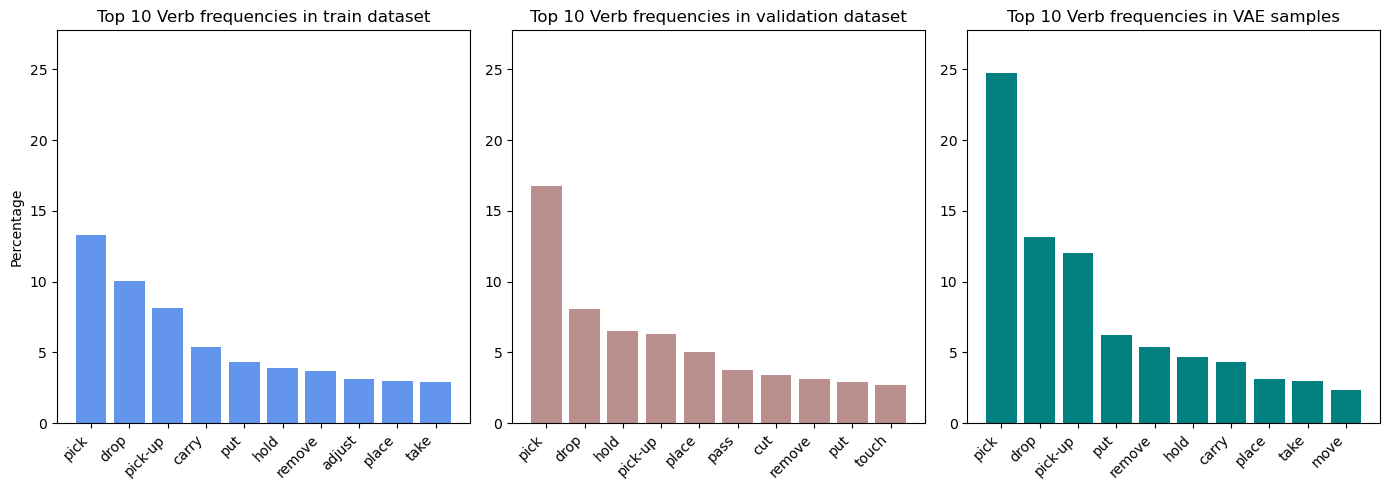

In [39]:
from evaluation_utils import compare_statistics
verbs_list_original = [triplet[0].item() for triplets in triplets_original for triplet in triplets]
verbs_list_val = [triplet[0].item() for triplets in triplets_original_val for triplet in triplets]
verbs_list_vae = [triplet[0].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics_v2(verbs_list_original, verbs_list_val, verbs_list_vae, verbs, 'train dataset', 'validation dataset', 'VAE samples', 'Verb')

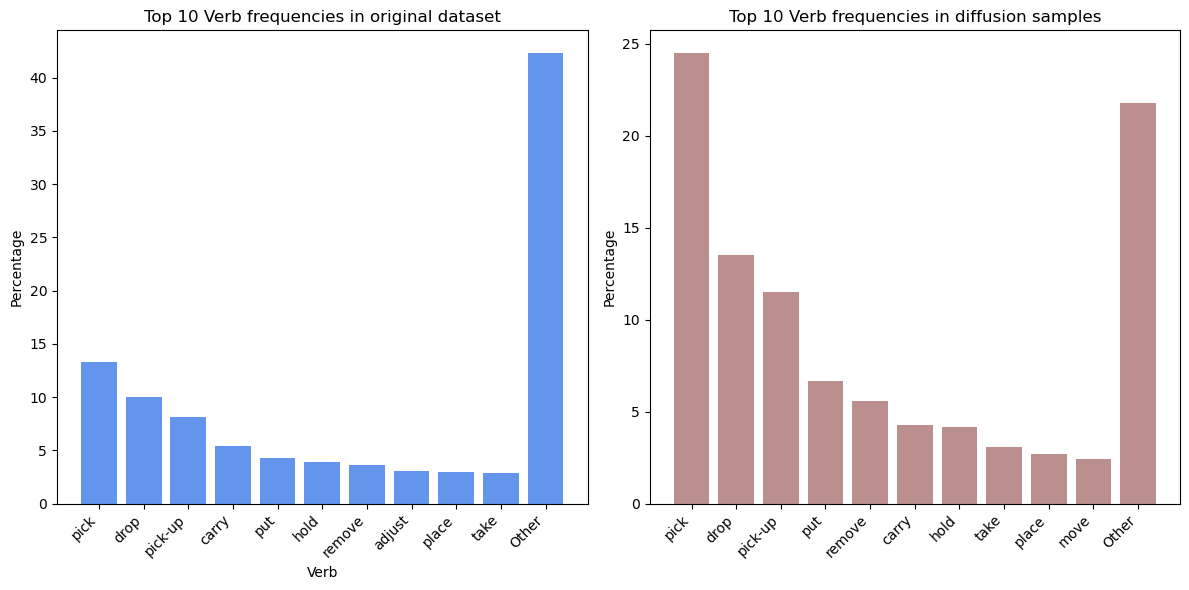

(Counter({89: 1128,
          36: 850,
          91: 691,
          12: 458,
          108: 365,
          58: 328,
          115: 310,
          1: 262,
          92: 255,
          162: 247,
          79: 212,
          82: 172,
          98: 142,
          174: 138,
          26: 128,
          86: 111,
          103: 101,
          104: 99,
          102: 88,
          177: 80,
          18: 74,
          29: 74,
          69: 70,
          30: 69,
          193: 69,
          119: 68,
          21: 68,
          120: 63,
          173: 63,
          124: 59,
          85: 58,
          178: 58,
          49: 55,
          65: 55,
          181: 53,
          112: 47,
          4: 47,
          164: 45,
          60: 40,
          132: 40,
          77: 39,
          154: 34,
          105: 33,
          122: 29,
          109: 28,
          10: 27,
          5: 27,
          84: 25,
          34: 24,
          126: 24,
          13: 24,
          95: 23,
          72: 20,
        

In [101]:
compare_statistics(verbs_list_original, verbs_list_vae, verbs, 'original dataset', 'diffusion samples', 'Verb', other=True)

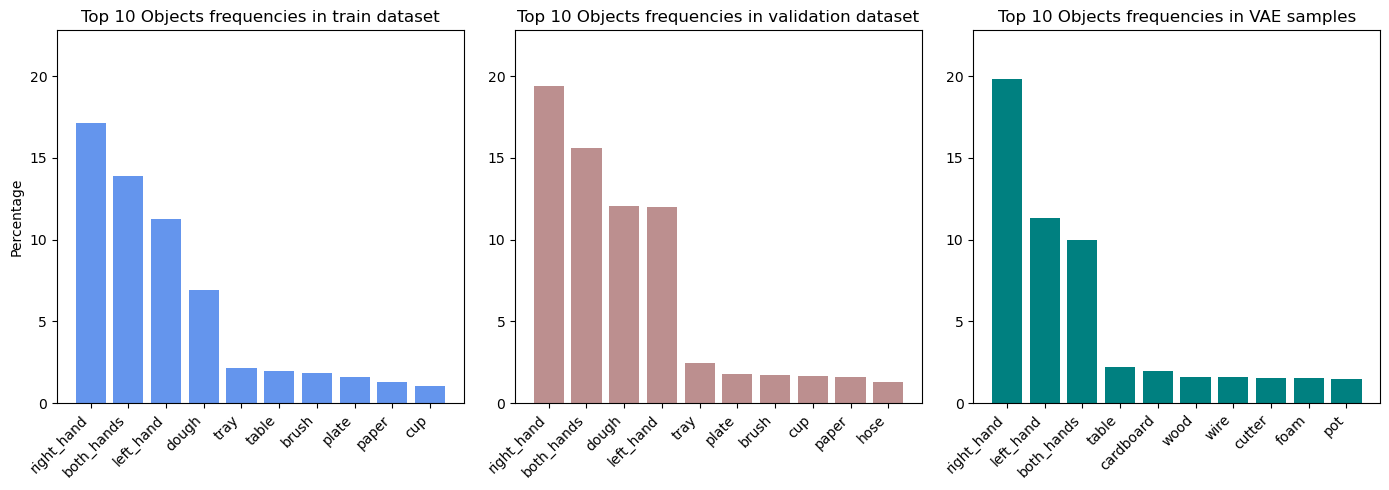

In [40]:
objs_list_original = [triplet[1].item() for triplets in triplets_original for triplet in triplets]
objs_list_val = [triplet[1].item() for triplets in triplets_original_val for triplet in triplets]
objs_list_vae = [triplet[1].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics_v2(objs_list_original, objs_list_vae, objs_list_val, objs, 'train dataset','validation dataset', 'VAE samples', 'Objects', other=False)

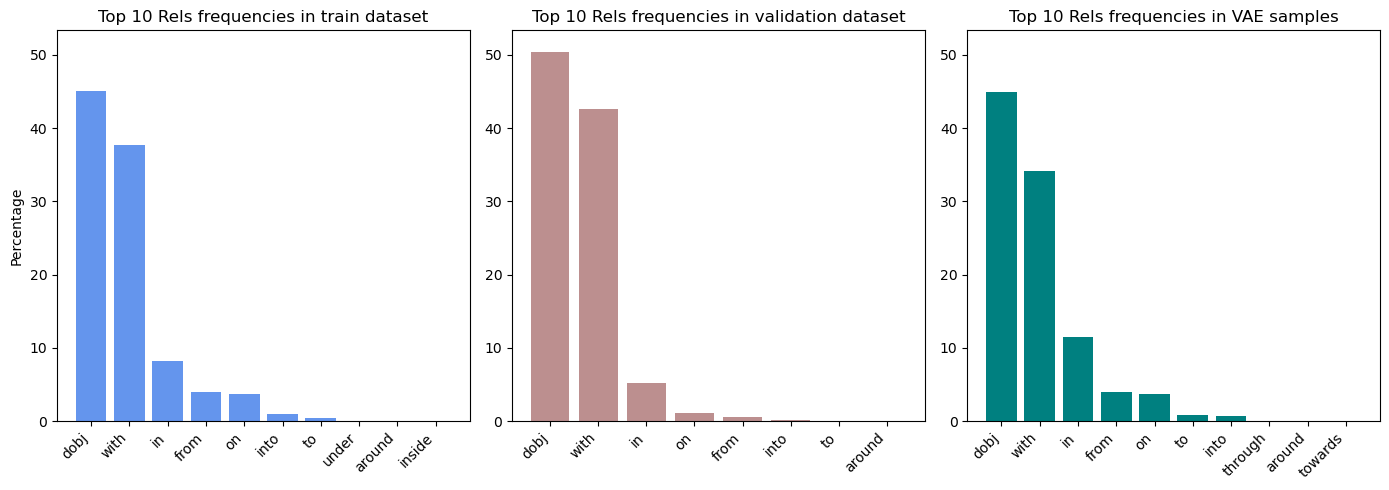

In [44]:
rels_list_original = [triplet[2].item() for triplets in triplets_original for triplet in triplets]
rels_list_original_val = [triplet[2].item() for triplets in triplets_original_val for triplet in triplets]
rels_list_diffusion = [triplet[2].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics_v2(rels_list_original, rels_list_diffusion, rels_list_original_val, rels, 'train dataset', 'validation dataset', 'VAE samples', 'Rels', other=False)

# t-SNE

In [15]:
import numpy as np
from sklearn.manifold import TSNE

# Step 1: Obtain Latent Representations from the VAE
vae.eval()  # Set VAE to evaluation mode
latent_vectors = []
verb_labels = []
object_labels = []
relationship_labels = []

with torch.no_grad():
    for data in train_loader:
        batch, v_gt, rel_gt = data
        objs = (rel_gt == 1).nonzero(as_tuple=False)
        objects = objs[objs[:, 2] != 13][:,1]
        # rels = objs[objs[:, 2]][:, 2]
        rels = objs[objs[:, 2] != 13][:, 2]
        batch = batch.to(device)
        z = vae.encode(batch)
        latent_vectors.append(z.cpu().numpy())
        verb_labels.append(v_gt.cpu().numpy())
        object_labels.extend([el.cpu().numpy().item() for el in objects])
        relationship_labels.extend([el.cpu().numpy().item() for el in rels])

# Concatenate all latent vectors and labels into single arrays
latent_vectors = np.concatenate(latent_vectors, axis=0)
verb_labels = np.concatenate(verb_labels, axis=0)

# Step 2: Apply t-SNE to the Latent Vectors
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
latent_tsne = tsne.fit_transform(latent_vectors)

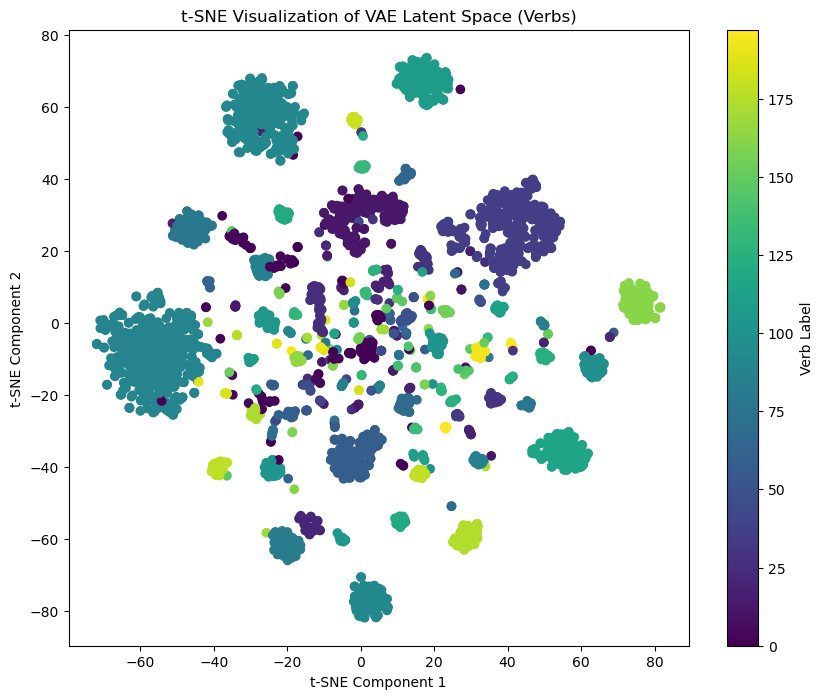

In [16]:
# Plot the t-SNE Visualization with verb labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=verb_labels, cmap='viridis')
plt.colorbar(scatter, label='Verb Label')
plt.title("t-SNE Visualization of VAE Latent Space (Verbs)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

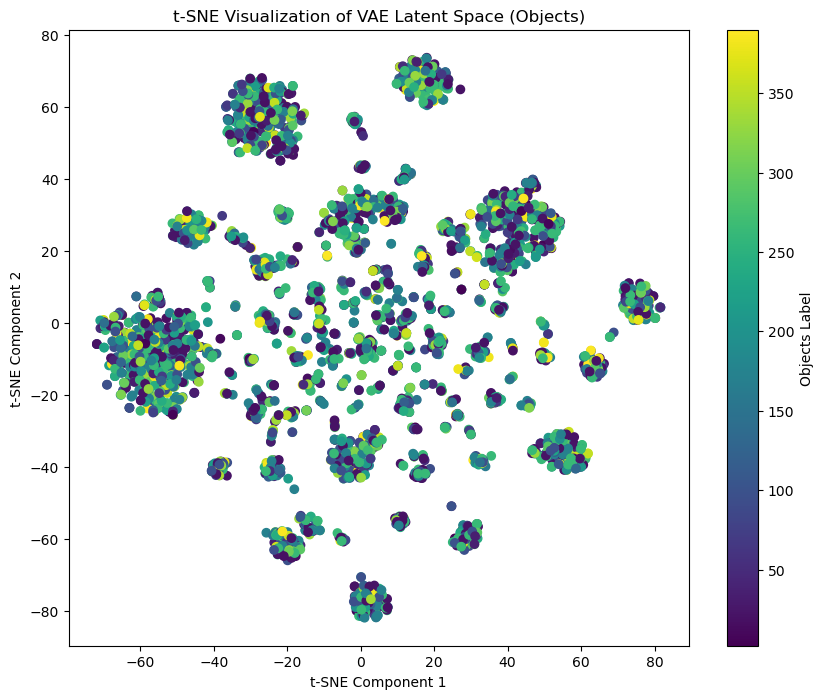

In [17]:
# Plot the t-SNE Visualization with object labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=object_labels[:len(train_dataset)], cmap='viridis')
plt.colorbar(scatter, label='Objects Label')
plt.title("t-SNE Visualization of VAE Latent Space (Objects)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

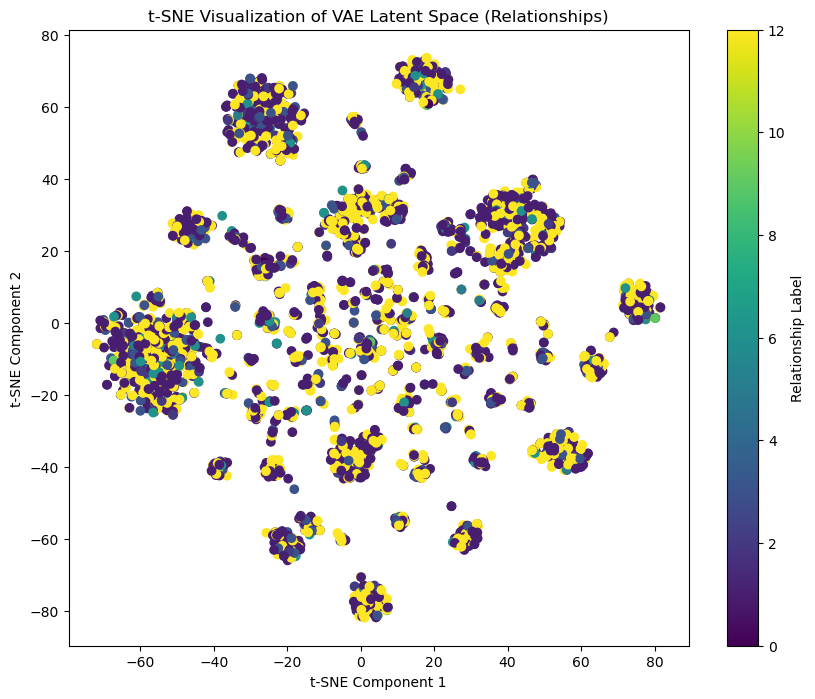

In [18]:
# Plot the t-SNE Visualization with relationship labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=relationship_labels[:len(train_dataset)], cmap='viridis')
plt.colorbar(scatter, label='Relationship Label')
plt.title("t-SNE Visualization of VAE Latent Space (Relationships)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()